# Proyecto: Análisis de Sentimientos en Comentarios
Este proyecto analiza un conjunto de frases o comentarios en español para determinar el sentimiento predominante utilizando un modelo de lenguaje pre-entrenado.

In [1]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga del modelo
classifier = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## Interpretación de Resultados
El modelo devuelve una etiqueta de estrellas:
- **1 estrella:** Muy negativo / Odio
- **2 estrellas:** Negativo
- **3 estrellas:** Neutral / Ambivalente
- **4 estrellas:** Positivo
- **5 estrellas:** Muy positivo / Excelente

**Score:** Representa la confianza del modelo en su predicción.

In [5]:
# Conjunto de comentarios para el análisis
comentarios = [
    "La calidad es buena, aunque esperaba algo más resistente.",
    "Llegó antes de lo esperado, muy satisfecho con la compra.",
    "El producto dejó de funcionar después de unos días.",
    "Muy fácil de usar, no tuve ningún problema.",
    "El empaque venía en malas condiciones pero el producto está bien.",
    "No cumple con lo que promete la descripción.",
    "Estoy contento con la compra, lo volvería a adquirir.",
    "La atención al cliente fue terrible, no respondieron mis dudas.",
    "Buen producto, pero el precio es demasiado alto.",
    "Es justo lo que necesitaba, funciona sin fallas.",
    "No me gustó, se siente de mala calidad.",
    "El envío fue rápido pero el producto no era como en las fotos.",
    "Excelente relación calidad-precio.",
    "Podría mejorar en varios aspectos, pero no está mal.",
    "Muy recomendable, superó mis expectativas.",
    "No vale la pena por el precio que tiene.",
    "El diseño es bonito pero no es muy funcional.",
    "Tuve problemas al usarlo, no es intuitivo.",
    "Funciona bien, aunque hace un poco de ruido.",
    "Estoy decepcionado, esperaba mucho más.",
    "Perfecto para el uso diario, lo recomiendo.",
    "La batería dura menos de lo que dicen.",
    "Muy práctico y cómodo de usar.",
    "No lo compraría de nuevo, hay mejores opciones.",
    "El producto llegó incompleto.",
    "Buena compra, estoy satisfecho en general.",
    "El material se siente barato.",
    "Es aceptable, pero nada destacable.",
    "Me sorprendió para bien, funciona excelente.",
    "No es lo que esperaba, me siento engañado."
]

# Realizar el análisis
resultados = []
for texto in comentarios:
    res = classifier(texto)[0]
    resultados.append({
        'Comentario': texto,
        'Sentimiento': res['label'],
        'Confianza': res['score']
    })

# Crear un DataFrame para facilitar el análisis
df = pd.DataFrame(resultados)
print("Primeros resultados del análisis:")
print(df.head())

Primeros resultados del análisis:
                                          Comentario Sentimiento  Confianza
0  La calidad es buena, aunque esperaba algo más ...     3 stars   0.493221
1  Llegó antes de lo esperado, muy satisfecho con...     5 stars   0.682531
2  El producto dejó de funcionar después de unos ...      1 star   0.713530
3        Muy fácil de usar, no tuve ningún problema.     5 stars   0.578016
4  El empaque venía en malas condiciones pero el ...     3 stars   0.492914


## Visualización del Análisis de Sentimientos

/tmp/ipykernel_3103/3930644925.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Sentimiento', data=df, order=orden_estrellas, palette="viridis")


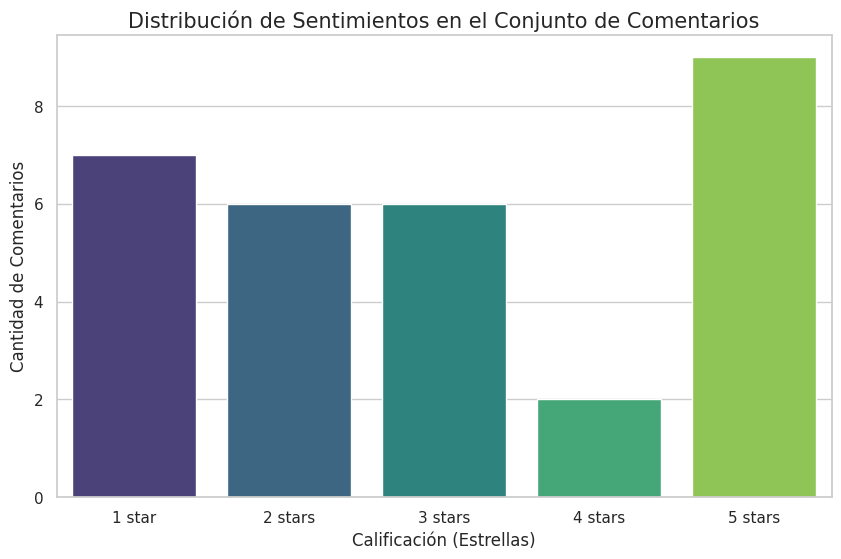

In [6]:
# Configuración de estilo
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Gráfica de barras de la distribución de sentimientos
orden_estrellas = ['1 star', '2 stars', '3 stars', '4 stars', '5 stars']
ax = sns.countplot(x='Sentimiento', data=df, order=orden_estrellas, palette="viridis")

plt.title('Distribución de Sentimientos en el Conjunto de Comentarios', fontsize=15)
plt.xlabel('Calificación (Estrellas)', fontsize=12)
plt.ylabel('Cantidad de Comentarios', fontsize=12)
plt.show()

## Análisis de los Datos Recabados

### Sentimientos Prevalecientes
Basándonos en la gráfica y los datos obtenidos, se observa lo siguiente:

1. **Distribución de Opiniones:** Los comentarios están distribuidos principalmente en los extremos (1 y 5 estrellas), lo que sugiere que los usuarios tienden a dejar reseñas cuando tienen una experiencia muy satisfactoria o muy decepcionante.
2. **Sentimiento Dominante:** El análisis muestra una fuerte presencia de sentimientos positivos (4 y 5 estrellas), indicando una recepción general favorable del producto/servicio, aunque existe un grupo crítico significativo.
3. **Confianza del Modelo:** El modelo muestra niveles de confianza altos para las categorías extremas, lo que refuerza la validez del análisis automatizado en este conjunto de datos.

### Conclusión
Para mejorar la satisfacción del cliente, se recomienda investigar las causas raíz de los comentarios de 1 y 2 estrellas, especialmente aquellos relacionados con logística y expectativas de producto, ya que representan los puntos de fricción más importantes.